In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(str(Path("..").resolve()))

# Load trained models with different seeds


In [2]:
from helpers import load_fitted_model

model_configurations = [
    ("hmm", 2, 42),
    ("hmm", 3, 42),
    ("hmm", 4, 42),  # Configurations with seed 42
    ("vdhmm", 2, 42),
    ("vdhmm", 3, 42),
    ("vdhmm", 4, 42),
    ("hmm", 2, 43),
    ("hmm", 3, 43),
    ("hmm", 4, 43),
    ("vdhmm", 2, 43),
    ("vdhmm", 3, 43),  # Configurations with seed 43
    ("vdhmm", 4, 43),
    ("hmm", 2, 123),
    ("hmm", 3, 123),
    ("hmm", 4, 123),  # Configurations with seed 123
    ("vdhmm", 2, 123),
    ("vdhmm", 3, 123),
    ("vdhmm", 4, 123),
    ("hmm", 2, None),  # Configuration with seed None (original indices)
    ("hmm", 3, None),
    ("hmm", 4, None),
    ("vdhmm", 2, None),  # Configuration with seed None (original indices)
    ("vdhmm", 3, None),
    ("vdhmm", 4, None),
]

n_models = len(model_configurations)

# get AUC and R_HAT metrics out of hmm models
results_df = pd.DataFrame(
    {
        "Model": [
            f"{model_name}_{S}" for (model_name, S, seed) in model_configurations
        ],
        "Seed": [
            seed if seed else "Original"
            for (model_name, S, seed) in model_configurations
        ],
        "AUC_TRAIN": [0.0] * n_models,
        "AUC_TEST": [0.0] * n_models,
        "R_HAT_MEAN": [0.0] * n_models,
        "R_HAT_STD": [0.0] * n_models,
    }
)

/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import arviz as az
from sklearn.metrics import roc_auc_score

from constants import PROCESSED_DATA_FOLDER
from helpers import ModelData

# Loop over all model configurations
for k, (model_name, S, seed) in enumerate(model_configurations):
    print(f"Processing {k+1}/{n_models}: {model_name} with {S} states (seed={seed})...")
    model_data = ModelData.from_pickle(
        PROCESSED_DATA_FOLDER / f"processed_data_{seed if seed else 'original'}.pkl"
    )
    eval_indices = model_data.eval_indices

    # Load the fitted model with the given seed
    try:
        model = load_fitted_model(model_name, S, seed=seed)
    except FileNotFoundError:
        print(
            f"FileNotFound: {model_name} with {S} states and seed {seed} was not found! Skipping..."
        )
        continue

    log_lik = model.fit.stan_variable("log_lik")
    log_lik_test = model.fit.stan_variable("log_lik_test")
    close_prob = model.fit.stan_variable("close_prob")
    close_prob_mean = close_prob.mean(axis=0)

    idata = az.from_cmdstanpy(model.fit, log_likelihood="log_lik")

    # Calculate AUC for training data (as percentage)
    y_true_train = np.array(model.stan_data["Closed"][:500])
    results_df.loc[k, "AUC_TRAIN"] = 100 * roc_auc_score(
        y_true_train, close_prob_mean[:500]
    )

    y_true_test = np.array(model.stan_data["Closed"])[eval_indices]

    # Take the mean for all businesses across all iterations
    close_prob_test_mean = np.mean(model.fit.stan_variable("close_prob"), axis=0)
    results_df.loc[k, "AUC_TEST"] = 100 * roc_auc_score(
        y_true_test, close_prob_mean[eval_indices]
    )

    # Use the already stored summary DataFrame (model.summary)
    # Calculate mean and std of R_hat across all parameters
    results_df.loc[k, "R_HAT_MEAN"] = np.nanmean(model.summary["R_hat"])
    results_df.loc[k, "R_HAT_STD"] = np.nanstd(model.summary["R_hat"])

print("\nResults:")

# Round results
results_df["AUC_TRAIN"] = results_df["AUC_TRAIN"].round(2)
results_df["AUC_TEST"] = results_df["AUC_TEST"].round(2)
results_df["R_HAT_MEAN"] = results_df["R_HAT_MEAN"].round(4)
results_df["R_HAT_STD"] = results_df["R_HAT_STD"].round(4)

np.random.seed(None)

results_df

Processing 1/24: hmm with 2 states (seed=42)...
Processing 2/24: hmm with 3 states (seed=42)...
Processing 3/24: hmm with 4 states (seed=42)...
Processing 4/24: vdhmm with 2 states (seed=42)...
Processing 5/24: vdhmm with 3 states (seed=42)...
Processing 6/24: vdhmm with 4 states (seed=42)...
Processing 7/24: hmm with 2 states (seed=43)...
Processing 8/24: hmm with 3 states (seed=43)...
Processing 9/24: hmm with 4 states (seed=43)...
Processing 10/24: vdhmm with 2 states (seed=43)...
Processing 11/24: vdhmm with 3 states (seed=43)...
Processing 12/24: vdhmm with 4 states (seed=43)...
Processing 13/24: hmm with 2 states (seed=123)...
Processing 14/24: hmm with 3 states (seed=123)...
Processing 15/24: hmm with 4 states (seed=123)...
Processing 16/24: vdhmm with 2 states (seed=123)...
Processing 17/24: vdhmm with 3 states (seed=123)...
Processing 18/24: vdhmm with 4 states (seed=123)...
Processing 19/24: hmm with 2 states (seed=None)...
Processing 20/24: hmm with 3 states (seed=None)...
P

,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
0,hmm_2,42,79.86,80.09,1.0006,0.0007
1,hmm_3,42,83.83,83.54,1.3394,0.2104
2,hmm_4,42,83.60,83.13,1.6289,0.4337
3,vdhmm_2,42,79.26,79.76,1.3574,0.2292
4,vdhmm_3,42,85.36,84.86,1.0010,0.0009
5,vdhmm_4,42,85.78,85.15,1.5874,0.3723
6,hmm_2,43,82.24,73.63,1.0006,0.0007
7,hmm_3,43,84.48,78.03,1.3344,0.2133
8,hmm_4,43,85.90,79.35,1.2905,0.2101
9,vdhmm_2,43,82.85,71.46,1.0008,0.0008


In [4]:
# Split results for different seeds
grouped_dfs = {}

for seed, group_df in results_df.groupby("Seed"):
    grouped_dfs[seed] = group_df.copy()

print("\n" + "=" * 60)
print("SEED 42:")
print(60 * "=")
display(grouped_dfs[42])


print("\n" + "=" * 60)
print("SEED 43:")
print(60 * "=")
display(grouped_dfs[43])


print("\n" + "=" * 60)
print("SEED 123:")
print(60 * "=")
display(grouped_dfs[123])

print("\n" + "=" * 60)
print("ORIGINAL INDICES")
print(60 * "=")
display(grouped_dfs["Original"])


SEED 42:


,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
0,hmm_2,42,79.86,80.09,1.0006,0.0007
1,hmm_3,42,83.83,83.54,1.3394,0.2104
2,hmm_4,42,83.60,83.13,1.6289,0.4337
3,vdhmm_2,42,79.26,79.76,1.3574,0.2292
4,vdhmm_3,42,85.36,84.86,1.0010,0.0009
5,vdhmm_4,42,85.78,85.15,1.5874,0.3723



SEED 43:


,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
6,hmm_2,43,82.24,73.63,1.0006,0.0007
7,hmm_3,43,84.48,78.03,1.3344,0.2133
8,hmm_4,43,85.90,79.35,1.2905,0.2101
9,vdhmm_2,43,82.85,71.46,1.0008,0.0008
10,vdhmm_3,43,86.14,81.18,1.0019,0.0017
11,vdhmm_4,43,86.32,79.60,1.7999,0.5237



SEED 123:


,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
12,hmm_2,123,78.44,77.76,1.3746,0.2151
13,hmm_3,123,82.20,80.17,1.4801,0.2884
14,hmm_4,123,83.30,81.85,1.6709,0.4124
15,vdhmm_2,123,78.21,77.58,1.0009,0.0008
16,vdhmm_3,123,84.19,82.91,1.7911,0.4310
17,vdhmm_4,123,84.19,83.22,1.4819,0.3928



ORIGINAL INDICES


,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
18,hmm_2,Original,78.53,77.14,1.0010,0.0011
19,hmm_3,Original,81.81,82.39,1.3345,0.2149
20,hmm_4,Original,82.68,83.71,1.6543,0.4159
21,vdhmm_2,Original,78.27,76.40,1.3539,0.2286
22,vdhmm_3,Original,83.93,84.39,1.0007,0.0008
23,vdhmm_4,Original,82.99,83.48,1.6784,0.4346


# Robustness Analysis: Seed Variability

---

## Statistische Analyse der Model-Robustheit

Analyse der Performance-Stabilität der HMM und VDHMM Modelle über verschiedene Seeds hinweg


In [5]:
# Teile Modellname (HMM_2) in Modeltyp (HMM) und Anzahl Zustände (2)
results_df["Model_Type"] = results_df["Model"].str.split("_").str[0].str.upper()
results_df["States"] = results_df["Model"].str.split("_").str[1].astype(int)


print("=" * 110)
print("HMM ROBUSTNESS DATA (All Seeds: 42, 43, 123)")
print("=" * 110)
print(
    results_df[
        ["Model_Type", "States", "Seed", "AUC_TRAIN", "AUC_TEST", "R_HAT_MEAN"]
    ].to_string(index=False)
)

# Berechne Statistiken pro Modellkonfiguration
robustness_stats = (
    results_df.groupby(["Model_Type", "States"])
    .agg(
        {
            "AUC_TEST": ["mean", "std", "min", "max"],
            "AUC_TRAIN": ["mean", "std"],
            "R_HAT_MEAN": ["mean", "max"],
        }
    )
    .round(2)
)

# Flatten multi-level columns
robustness_stats.columns = [
    "_".join(col).strip() for col in robustness_stats.columns.values
]
robustness_stats = robustness_stats.reset_index()

# Berechne Coefficient of Variation (CV) für AUC_TEST in Prozent
robustness_stats["AUC_TEST_CV_%"] = (
    robustness_stats["AUC_TEST_std"] / robustness_stats["AUC_TEST_mean"] * 100
).round(2)

# Berechne Range für AUC_TEST
robustness_stats["AUC_TEST_Range"] = (
    robustness_stats["AUC_TEST_max"] - robustness_stats["AUC_TEST_min"]
).round(2)

print("\n" + "=" * 110)
print("ROBUSTNESS STATISTICS: Mean ± Std across Seeds")
print("=" * 110)
print(robustness_stats.to_string(index=False))

# Identifiziere die robustesten Modelle (niedrigster CV%)
print("\n" + "=" * 110)
print("ROBUSTNESS RANKING (by Coefficient of Variation)")
print("=" * 110)
robustness_ranking = robustness_stats.sort_values("AUC_TEST_CV_%")
print(
    robustness_ranking[
        [
            "Model_Type",
            "States",
            "AUC_TEST_mean",
            "AUC_TEST_std",
            "AUC_TEST_CV_%",
            "AUC_TEST_Range",
        ]
    ].to_string(index=False)
)

HMM ROBUSTNESS DATA (All Seeds: 42, 43, 123)
Model_Type  States     Seed  AUC_TRAIN  AUC_TEST  R_HAT_MEAN
       HMM       2       42      79.86     80.09      1.0006
       HMM       3       42      83.83     83.54      1.3394
       HMM       4       42      83.60     83.13      1.6289
     VDHMM       2       42      79.26     79.76      1.3574
     VDHMM       3       42      85.36     84.86      1.0010
     VDHMM       4       42      85.78     85.15      1.5874
       HMM       2       43      82.24     73.63      1.0006
       HMM       3       43      84.48     78.03      1.3344
       HMM       4       43      85.90     79.35      1.2905
     VDHMM       2       43      82.85     71.46      1.0008
     VDHMM       3       43      86.14     81.18      1.0019
     VDHMM       4       43      86.32     79.60      1.7999
       HMM       2      123      78.44     77.76      1.3746
       HMM       3      123      82.20     80.17      1.4801
       HMM       4      123      83.30  

## Visualisierung: Seed Variability


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setze Seaborn Style
sns.set_style("whitegrid")

### 2. Mean AUC Test with Standard Deviation (Error Bars)

**Interpretation:**

- Bars show the mean AUC across all seeds
- Error bars show the standard deviation
- Smaller error bars = higher robustness


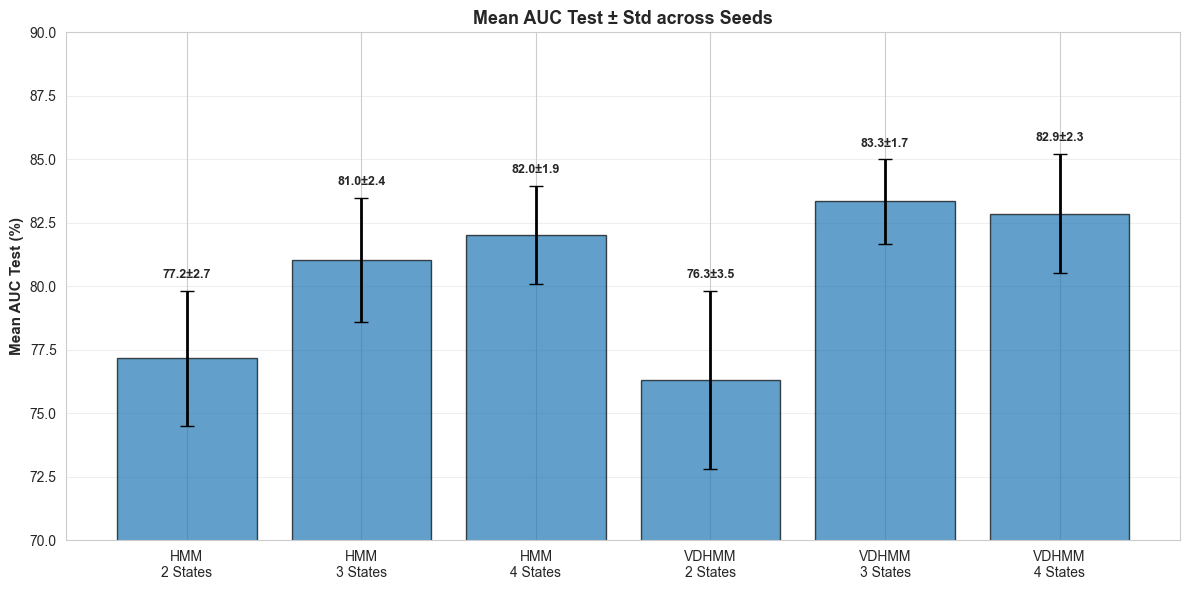

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(robustness_stats))

bars = ax.bar(
    x_pos,
    robustness_stats["AUC_TEST_mean"],
    yerr=robustness_stats["AUC_TEST_std"],
    alpha=0.7,
    edgecolor="black",
    capsize=5,
    error_kw={"linewidth": 2},
)

ax.set_ylabel("Mean AUC Test (%)", fontsize=11, fontweight="bold")
ax.set_title("Mean AUC Test ± Std across Seeds", fontsize=13, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(
    [
        f"{row['Model_Type']}\n{row['States']} States"
        for _, row in robustness_stats.iterrows()
    ],
    fontsize=10,
)
ax.set_ylim([70, 90])
ax.grid(axis="y", alpha=0.3)

# Values above bars
for i, (mean, std) in enumerate(
    zip(robustness_stats["AUC_TEST_mean"], robustness_stats["AUC_TEST_std"])
):
    ax.text(
        i,
        mean + std + 0.5,
        f"{mean:.1f}±{std:.1f}",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

### 3. Coefficient of Variation (CV%) - Robustness Ranking

**Interpretation:**

- Coefficient of Variation (CV%) = Standard Deviation / Mean × 100
- Lower CV% = more robust model (less relative variability)
- CV% < 3% is considered very robust (which would mean a difference of ±2.5%)


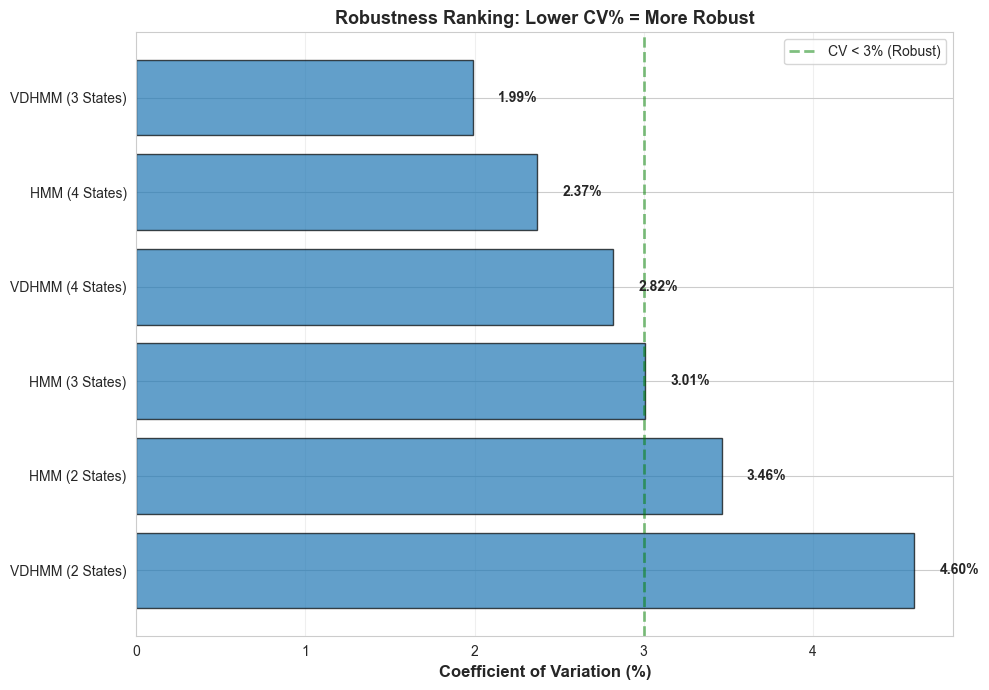

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

cv_sorted = robustness_stats.sort_values("AUC_TEST_CV_%")
x_pos = np.arange(len(cv_sorted))

bars = ax.barh(x_pos, cv_sorted["AUC_TEST_CV_%"], alpha=0.7, edgecolor="black")

ax.set_xlabel("Coefficient of Variation (%)", fontsize=12, fontweight="bold")
ax.set_title(
    "Robustness Ranking: Lower CV% = More Robust", fontsize=13, fontweight="bold"
)
ax.set_yticks(x_pos)
ax.set_yticklabels(
    [
        f"{row['Model_Type']} ({row['States']} States)"
        for _, row in cv_sorted.iterrows()
    ],
    fontsize=10,
)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

# Values next to bars
for i, cv in enumerate(cv_sorted["AUC_TEST_CV_%"]):
    ax.text(cv + 0.15, i, f"{cv:.2f}%", va="center", fontsize=10, fontweight="bold")

# Mark highly robust models (CV < 3%)
ax.axvline(
    x=3,
    color="green",
    linestyle="--",
    linewidth=2,
    alpha=0.5,
    label="CV < 3% (Robust)",
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 4. Heatmap: Model × Seed Performance Matrix

**Interpretation:**

- Green cells = high performance, yellow = medium, red = low performance
- Consistent colors across seeds = robust models
- VDHMM (3/4 States) shows consistently green values (>80% AUC)
- HMM (2 States) with Seed 43 and VDHMM (2 States) with Seed 43 show weaknesses (~72-74% AUC)


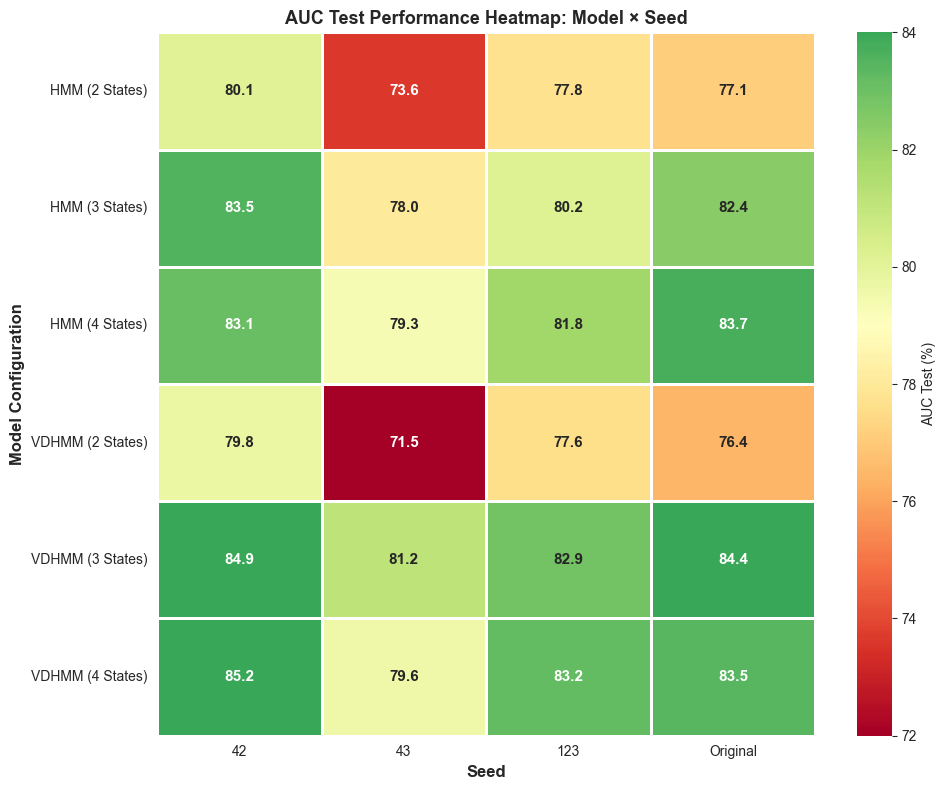

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

# Pivot table for heatmap
pivot_data = results_df.pivot_table(
    values="AUC_TEST", index=["Model_Type", "States"], columns="Seed"
)

# Create labels
row_labels = [f"{mt} ({s} States)" for mt, s in pivot_data.index]

sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=79,
    vmin=72,
    vmax=84,
    cbar_kws={"label": "AUC Test (%)"},
    yticklabels=row_labels,
    ax=ax,
    linewidths=1,
    annot_kws={"fontsize": 11, "fontweight": "bold"},
)

ax.set_xlabel("Seed", fontsize=12, fontweight="bold")
ax.set_ylabel("Model Configuration", fontsize=12, fontweight="bold")
ax.set_title(
    "AUC Test Performance Heatmap: Model × Seed", fontsize=13, fontweight="bold"
)

plt.tight_layout()
plt.show()

In [10]:
# Robustness summary
print("=" * 100)
print("ROBUSTNESS SUMMARY: Top 3 Most Robust Models")
print("=" * 100)

top3_robust = robustness_ranking.head(3)

for i, (idx, row) in enumerate(top3_robust.iterrows(), 1):
    print(f"\n{i}. {row['Model_Type']} ({row['States']} States)")
    print(f"   - Mean AUC Test: {row['AUC_TEST_mean']:.2f}%")
    print(f"   - Std: ±{row['AUC_TEST_std']:.2f}%")
    print(f"   - Coefficient of Variation (CV): {row['AUC_TEST_CV_%']:.2f}%")
    print(
        f"   - Range: {row['AUC_TEST_Range']:.2f}% (Min: {row['AUC_TEST_min']:.2f}%, Max: {row['AUC_TEST_max']:.2f}%)"
    )
    print(
        f"   - Mean R-hat: {row['R_HAT_MEAN_mean']:.4f} (Max: {row['R_HAT_MEAN_max']:.4f})"
    )

ROBUSTNESS SUMMARY: Top 3 Most Robust Models

1. VDHMM (3 States)
   - Mean AUC Test: 83.34%
   - Std: ±1.66%
   - Coefficient of Variation (CV): 1.99%
   - Range: 3.68% (Min: 81.18%, Max: 84.86%)
   - Mean R-hat: 1.2000 (Max: 1.7900)

2. HMM (4 States)
   - Mean AUC Test: 82.01%
   - Std: ±1.94%
   - Coefficient of Variation (CV): 2.37%
   - Range: 4.36% (Min: 79.35%, Max: 83.71%)
   - Mean R-hat: 1.5600 (Max: 1.6700)

3. VDHMM (4 States)
   - Mean AUC Test: 82.86%
   - Std: ±2.34%
   - Coefficient of Variation (CV): 2.82%
   - Range: 5.55% (Min: 79.60%, Max: 85.15%)
   - Mean R-hat: 1.6400 (Max: 1.8000)


# Check posterior means of proposed model


/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (2939), generating only 20 plots
  warnings.warn(


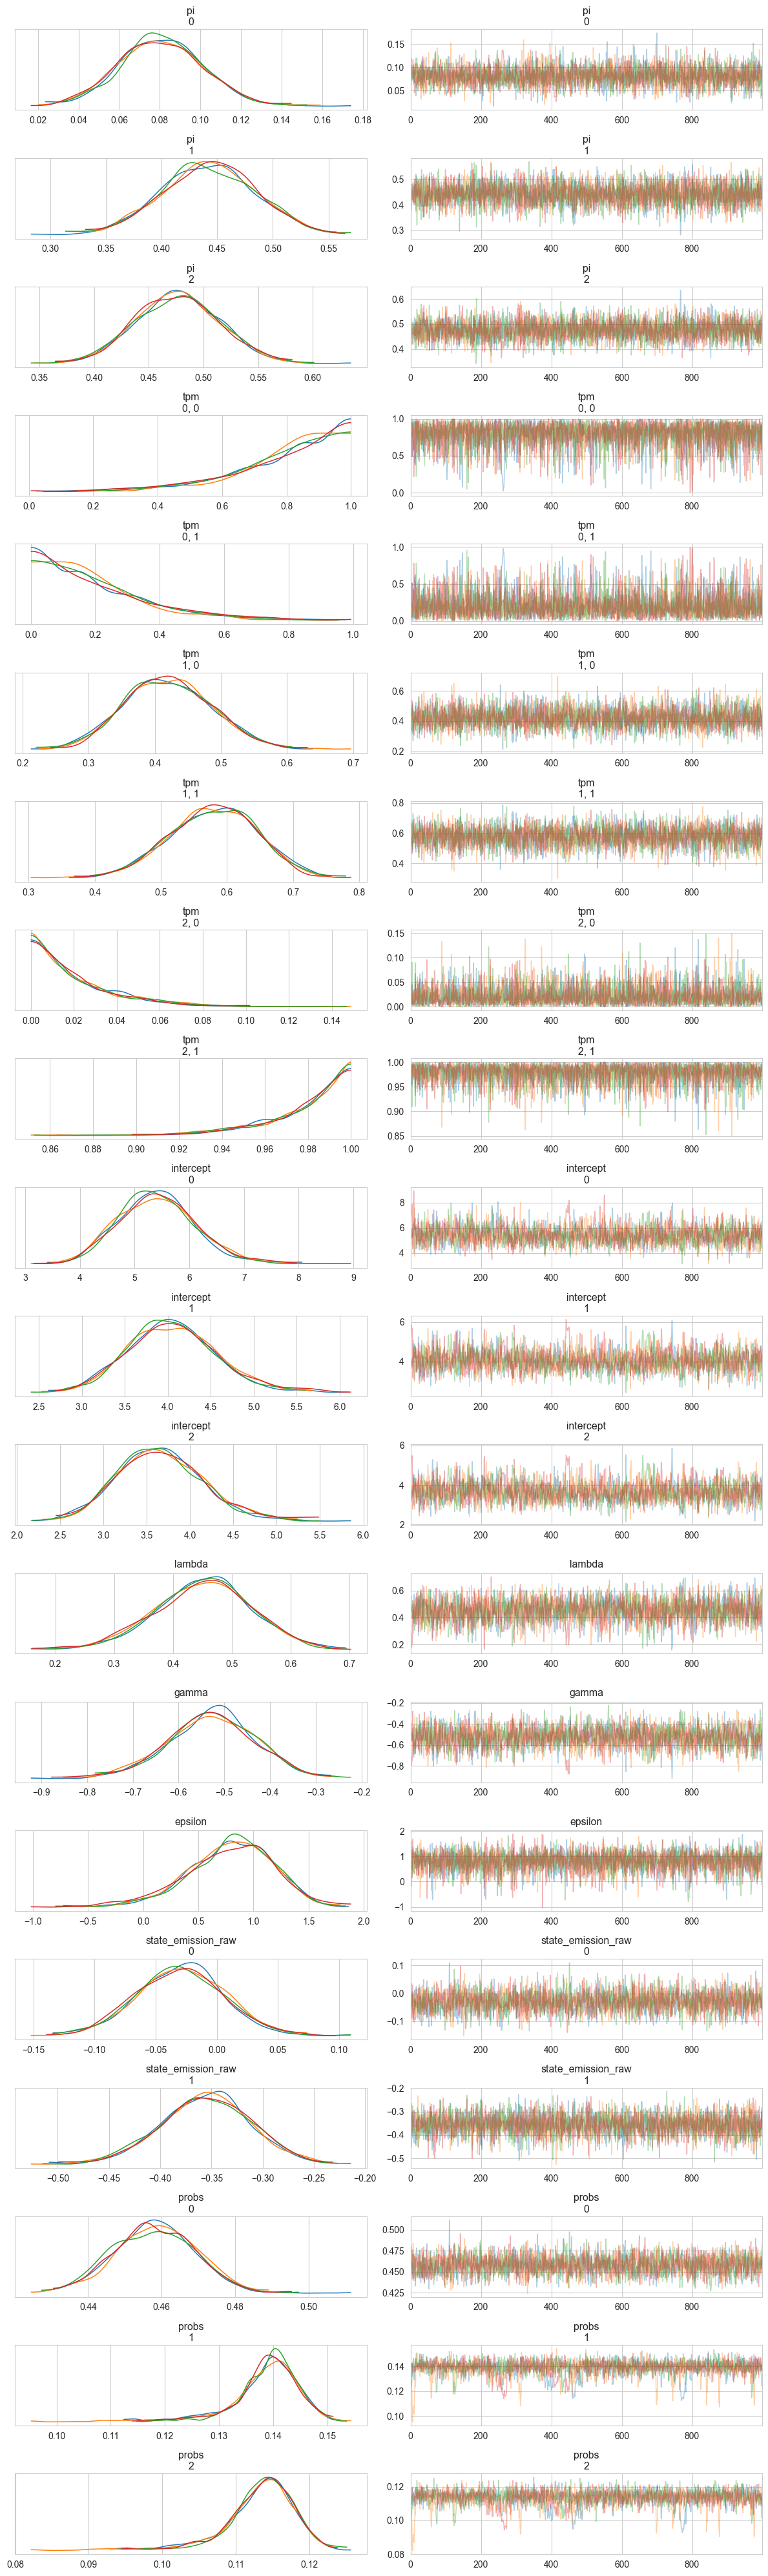

/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (2939) in plot_posterior, generating only 40 plots
  warnings.warn(


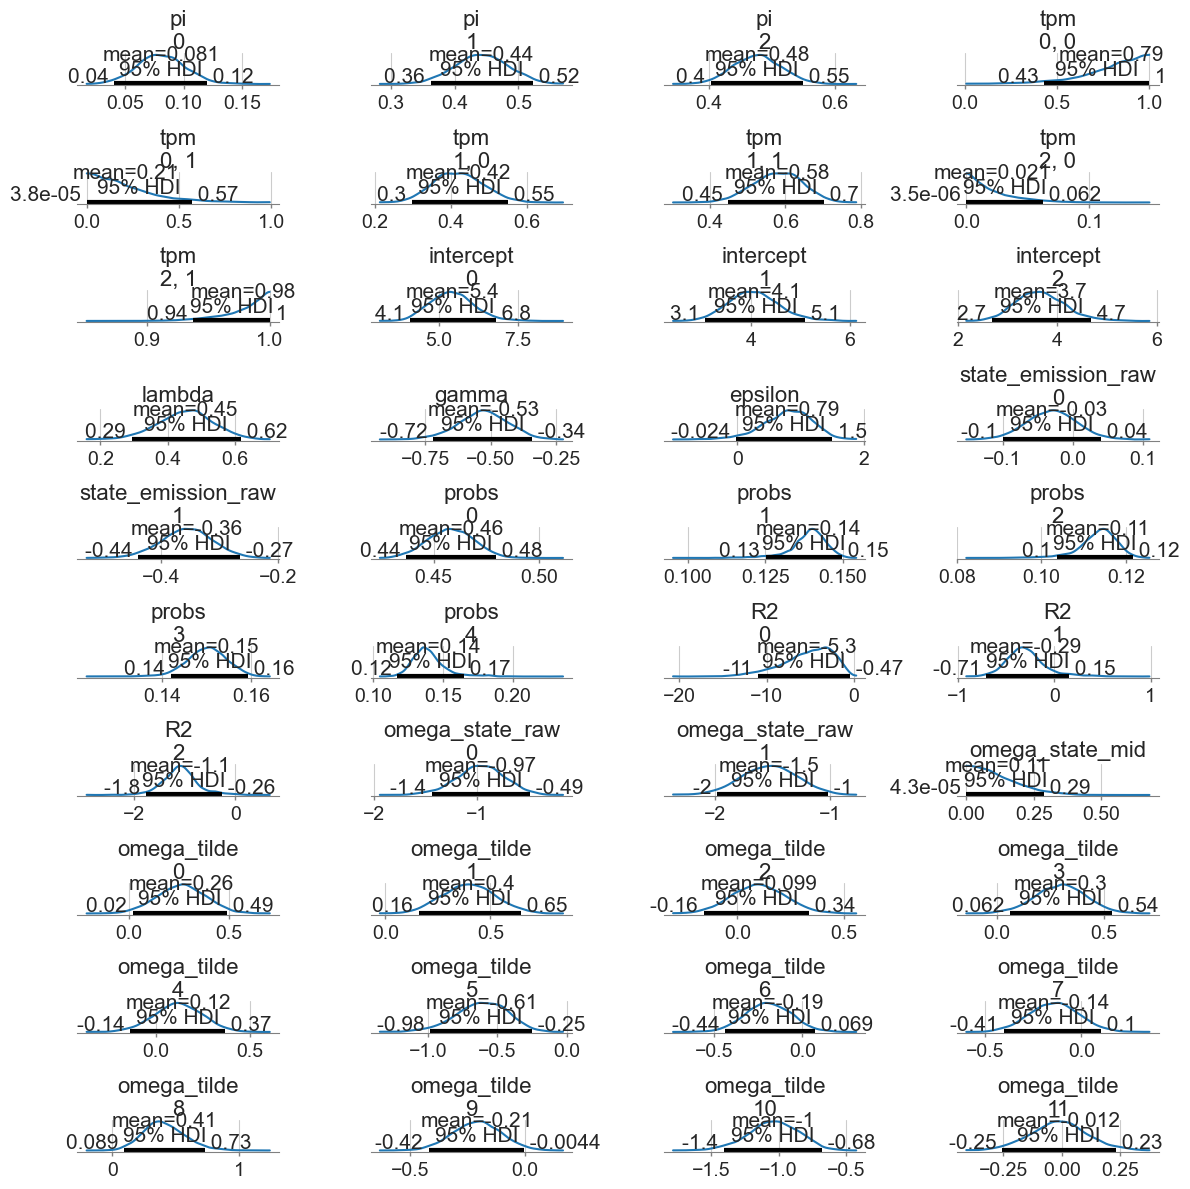

In [ ]:
from typing import List, Literal
from helpers import Model, load_fitted_model
import arviz as az
import matplotlib.pyplot as plt

az.rcParams["stats.ci_prob"] = 0.95  # set CI to 95%


def plot_posterior_distributions(
    model: Model,
    var_names: List[str] = [
        "intercept",
        "lambda",
        "gamma",
        "epsilon",
        "state_emission_raw",
        "omega_0",
        "omega_state",
    ],
    get_chain_progression: bool | Literal["both"] = True,
):

    inference_data = az.from_cmdstanpy(model.fit)

    if get_chain_progression:
        az.plot_trace(
            inference_data,
            var_names=var_names,
            compact=False,
        )
        plt.tight_layout()
        plt.show()

    az.plot_posterior(inference_data, var_names=var_names, figsize=(12, 12))
    plt.tight_layout()
    plt.show()


proposed_model = load_fitted_model("vdhmm", S=3)

plot_posterior_distributions(proposed_model, var_names=["state"])

In [67]:
def get_posterior_results(
    model: Model,
    var_names=[
        "intercept",
        "lambda",
        "gamma",
        "epsilon",
        "state_emission_raw",
        "omega_0",
        "omega_state",
    ],
):
    df = model.summary[["Mean", "StdDev", "5%", "95%", "R_hat"]]
    return df[
        df.index.str.contains("omega", case=False) | df.index.str.contains("lambda")
    ]


get_posterior_results(proposed_model)

,Mean,StdDev,5%,95%,R_hat
lambda,0.451761,0.082522,0.310076,0.583968,1.001250
omega_state_raw[1],-0.967972,0.237072,-1.371170,-0.590776,1.000180
omega_state_raw[2],-1.528080,0.245647,-1.934770,-1.127180,1.000900
omega_state_mid,0.114288,0.088170,0.009295,0.288596,1.000870
omega_tilde[1],0.263751,0.122418,0.060322,0.464465,1.001790
omega_tilde[2],0.397269,0.125604,0.192436,0.607992,1.000280
omega_tilde[3],0.099341,0.126884,-0.107859,0.309185,1.000040
omega_tilde[4],0.298245,0.120360,0.097333,0.493486,1.004540
omega_tilde[5],0.118354,0.128071,-0.095150,0.326659,0.999716
omega_tilde[6],-0.613624,0.187861,-0.938681,-0.324418,1.000170


In [79]:
# =============================================================================
# STATE-RATING DISTRIBUTION TABLE (wie Paper Table 3)
# =============================================================================

from helpers import load_fitted_model
import numpy as np
import pandas as pd
from scipy.special import expit
from scipy.stats import norm

# Load the proposed model
model = load_fitted_model("vdhmm", S=3)

# Extract parameters from Stan output
summary = model.summary

# Get state emission parameters
state_emission_raw = []
for s in range(1, 3):  # S-1 states (first state is reference with 0)
    param_name = f"state_emission_raw[{s}]"
    state_emission_raw.append(summary.loc[param_name, "Mean"])

# Get R2 values
R2_values = []
for s in range(1, 4):  # All S states
    param_name = f"R2[{s}]"
    R2_values.append(summary.loc[param_name, "Mean"])

# Get cut points (probs)
probs = []
for r in range(1, 5):  # 4 cut points for 5 ratings
    param_name = f"probs[{r}]"
    probs.append(summary.loc[param_name, "Mean"])

print("=" * 80)
print("EXTRACTED PARAMETERS")
print("=" * 80)
print(f"state_emission_raw: {state_emission_raw}")
print(f"R2 values: {R2_values}")
print(f"probs: {probs}")

# =============================================================================
# CALCULATE STATE EMISSIONS (following Stan code logic)
# =============================================================================

# Calculate state_emission values (cumulative sum with exp transformation)
state_emission = [0.0]  # First state is 0
for i, raw_val in enumerate(state_emission_raw):
    state_emission.append(state_emission[-1] + np.exp(raw_val))

print(f"\nstate_emission (η_s): {state_emission}")

# Calculate emission probabilities for each state
emission_probs = pd.DataFrame(
    index=[f"State {s+1}" for s in range(3)],
    columns=["5 stars", "4 stars", "3 stars", "2 stars", "1 star"],
)

# Calculate cumulative probs for cut points
cumsum_probs = np.cumsum(probs)
print(f"\nCumulative probs: {cumsum_probs}")

for s in range(3):
    # Calculate scale factor
    scale = 1 / np.sqrt(1 - expit(R2_values[s]))

    # Calculate cut points
    cuts = scale * norm.ppf(cumsum_probs)

    # Calculate emission probabilities using ordered probit
    eta = state_emission[s]

    # P(Rating = 1)
    emission_probs.iloc[s, 4] = 1 - norm.cdf(eta - cuts[0])

    # P(Rating = 2, 3, 4)
    for r in range(1, 4):
        emission_probs.iloc[s, 4 - r] = norm.cdf(eta - cuts[r - 1]) - norm.cdf(
            eta - cuts[r]
        )

    # P(Rating = 5)
    emission_probs.iloc[s, 0] = norm.cdf(eta - cuts[3])

# Convert to percentages
emission_probs = emission_probs.astype(float) * 100

# Calculate mean ratings
mean_ratings = []
for s in range(3):
    mean_rating = (
        sum(
            [
                5 * emission_probs.iloc[s, 0],
                4 * emission_probs.iloc[s, 1],
                3 * emission_probs.iloc[s, 2],
                2 * emission_probs.iloc[s, 3],
                1 * emission_probs.iloc[s, 4],
            ]
        )
        / 100
    )
    mean_ratings.append(mean_rating)

emission_probs["Mean Rating"] = mean_ratings

# =============================================================================
# IDENTIFY STATES BY MEAN RATING
# =============================================================================

# Sort states by mean rating
state_order = np.argsort(mean_ratings)[::-1]  # Descending order

# Assign state names based on mean rating and omega_state sign
state_names = []
omega_states = []

for idx in state_order:
    omega_val = summary.loc[f"omega_state[{idx+1}]", "Mean"]
    omega_states.append(omega_val)

    if omega_val > 0:
        state_names.append(f"State {idx+1}: At Risk (ω={omega_val:.3f})")
    elif mean_ratings[idx] > 4.0:
        state_names.append(f"State {idx+1}: Well Running (ω={omega_val:.3f})")
    else:
        state_names.append(
            f"State {idx+1}: Bad Ratings but Running (ω={omega_val:.3f})"
        )

# Reorder table
emission_probs_sorted = emission_probs.iloc[state_order].copy()
emission_probs_sorted.index = state_names

# =============================================================================
# DISPLAY RESULTS (like Paper Table 3)
# =============================================================================

print("\n" + "=" * 80)
print("STATE-DEPENDENT RATING DISTRIBUTION (Table 3 from Paper)")
print("=" * 80)
print("\nEmission Probabilities (%):")
print(emission_probs_sorted.round(2).to_string())

# Create a styled version
print("\n" + "=" * 80)
print("FORMATTED TABLE (ready for paper)")
print("=" * 80)
styled_table = emission_probs_sorted.round(2)
# print(styled_table.to_latex(float_format="%.2f"))

# =============================================================================
# COMPARE WITH PAPER VALUES
# =============================================================================

print("\n" + "=" * 80)
print("COMPARISON WITH PAPER TABLE 3")
print("=" * 80)

paper_values = pd.DataFrame(
    {
        "State": ["Well Running", "At Risk", "Bad Ratings but Running"],
        "5 stars": [66.09, 13.14, 32.31],
        "4 stars": [18.75, 15.08, 27.12],
        "3 stars": [6.92, 11.59, 14.69],
        "2 stars": [4.62, 14.26, 12.52],
        "1 star": [3.62, 45.93, 13.36],
        "Mean Rating": [4.51, 3.53, 2.16],
    }
)

print("\nPaper Values:")
print(paper_values.to_string(index=False))

print("\nYour Model:")
print(emission_probs_sorted.round(2))

# =============================================================================
# KEY INSIGHT: STATE IDENTIFICATION
# =============================================================================

print("\n" + "=" * 80)
print("STATE IDENTIFICATION LOGIC")
print("=" * 80)
print("\n✓ State mit POSITIVEM omega_state → 'At Risk'")
print("✓ State mit höchstem Mean Rating → 'Well Running'")
print("✓ State mit niedrigstem Mean Rating → 'Bad Ratings but Running'")
print("\nDeine States:")
for idx in range(3):
    omega_val = summary.loc[f"omega_state[{idx+1}]", "Mean"]
    print(
        f"  State {idx+1}: Mean Rating = {mean_ratings[idx]:.2f}, omega = {omega_val:.3f}"
    )

EXTRACTED PARAMETERS
state_emission_raw: [np.float64(-0.0296886), np.float64(-0.355903)]
R2 values: [np.float64(-5.31252), np.float64(-0.292994), np.float64(-1.09514)]
probs: [np.float64(0.458216), np.float64(0.13875), np.float64(0.113389), np.float64(0.149956)]

state_emission (η_s): [0.0, np.float64(0.9707477773445718), np.float64(1.671288346719467)]

Cumulative probs: [0.458216 0.596966 0.710355 0.860311]

STATE-DEPENDENT RATING DISTRIBUTION (Table 3 from Paper)

Emission Probabilities (%):
                                             5 stars  4 stars  3 stars  2 stars  1 star  Mean Rating
State 3: Well Running (ω=-1.528)               66.34    18.53     6.87     4.61    3.65         4.39
State 2: At Risk (ω=0.114)                     32.33    27.09    14.69    12.54   13.36         3.52
State 1: Bad Ratings but Running (ω=-0.968)    13.91    15.01    11.36    13.91   45.81         2.37

FORMATTED TABLE (ready for paper)

COMPARISON WITH PAPER TABLE 3

Paper Values:
                